# ДЗ7: Zero-Sum Linear Attention

Линейное внимание, которое возвращает линейному attention выразительность квадратичного softmax.

## Конфиг

In [21]:
import time
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

CONFIG = {
    "seed": 0,
    "d_model": 64,
    "n_heads": 4,
    "n_layers": 3,
    "d_ff": 128,
    "seq_len": 1024,
    "n_classes": 10,
    "batch_size": 128,
    "epochs": 3,
    "lr": 3e-4,
    "weight_decay": 0.05,
    "dropout": 0.1,
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
set_seed(CONFIG["seed"])
print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.11.0+cu128
Device: cuda


In [22]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def sync(dev):
    if dev.type == "cuda":
        torch.cuda.synchronize()


def timeit(fn, dev, warmup=3, iters=10):
    for _ in range(warmup):
        fn()
    sync(dev)
    start = time.perf_counter()
    for _ in range(iters):
        fn()
    sync(dev)
    return (time.perf_counter() - start) / iters


def peak_mem_mb(fn, dev):
    if dev.type != "cuda":
        fn()
        return float("nan")
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    fn()
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated() / 1024 ** 2


def show_table(rows):
    cols = list(rows[0])
    cells = [[str(r[c]) for c in cols] for r in rows]
    width = [max(len(c), *(len(row[j]) for row in cells)) for j, c in enumerate(cols)]
    line = "  ".join(c.ljust(width[j]) for j, c in enumerate(cols))
    print(line)
    print("  ".join("-" * width[j] for j in range(len(cols))))
    for row in cells:
        print("  ".join(v.ljust(width[j]) for j, v in enumerate(row)))

## Механизмы внимания

### Softmax MHA

Стандартное внимание за $O(N^2)$.

In [23]:
class SoftmaxAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = dropout

    def forward(self, x):
        B, L, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        out = F.scaled_dot_product_attention(q, k, v, dropout_p=self.dropout if self.training else 0.0)
        out = out.transpose(1, 2).reshape(B, L, D)
        return self.proj(out)

### Vanilla Linear Attention, Katharopoulos

In [24]:
class VanillaLinearAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    @staticmethod
    def feature(x):
        return F.elu(x) + 1.0

    def forward(self, x):
        B, L, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = self.feature(q.view(B, L, self.n_heads, self.d_head).transpose(1, 2))
        k = self.feature(k.view(B, L, self.n_heads, self.d_head).transpose(1, 2))
        v = v.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        kv = torch.einsum("bhld,bhle->bhde", k, v)
        z = k.sum(dim=2)
        num = torch.einsum("bhld,bhde->bhle", q, kv)
        den = torch.einsum("bhld,bhd->bhl", q, z).clamp_min(1e-6).unsqueeze(-1)
        out = (num / den).transpose(1, 2).reshape(B, L, D)
        return self.proj(out)

### ZeroS: прозрачная форма $O(N^2)$

In [25]:
class ZeroSExplicit(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0, use_associative=True, use_zero_order=False):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.use_associative = use_associative
        self.use_zero_order = use_zero_order
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.key_logit = nn.Linear(d_model, n_heads)
        self.gate = nn.Linear(d_model, 3 * n_heads)
        self.proj = nn.Linear(d_model, d_model)

    def split(self, t, B, L):
        return t.view(B, L, self.n_heads, -1).transpose(1, 2)

    def forward(self, x, return_weights=False):
        B, L, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = self.split(q, B, L)
        k = self.split(k, B, L)
        v = self.split(v, B, L)
        qn = q / q.norm(dim=-1, keepdim=True).clamp_min(1e-6)
        kn = k / k.norm(dim=-1, keepdim=True).clamp_min(1e-6)

        s = self.split(self.key_logit(x), B, L).squeeze(-1)
        t = float(L)
        s_full = s.unsqueeze(2).expand(B, self.n_heads, L, L)
        a = torch.softmax(s_full, dim=-1)
        delta = s_full - s_full.mean(dim=-1, keepdim=True)
        eps = a - 1.0 / t - delta / t

        g = self.split(self.gate(x), B, L)
        sig1 = torch.sigmoid(g[..., 0]).unsqueeze(-1)
        sigh = torch.sigmoid(g[..., 1]).unsqueeze(-1)
        sig0 = torch.tanh(g[..., 2]).unsqueeze(-1)

        w_base = sig1 * (delta / t) + sigh * eps
        if self.use_zero_order:
            w_base = w_base + sig0 * (1.0 / t)
        w = w_base
        if self.use_associative:
            cos = torch.matmul(qn, kn.transpose(-1, -2))
            w = w_base * cos

        out = torch.matmul(w, v).transpose(1, 2).reshape(B, L, D)
        out = self.proj(out)
        if return_weights:
            return out, w, w_base
        return out

### ZeroS линейная форма $O(N\,d^2)$

In [26]:
class ZeroSLinear(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0, use_zero_order=False):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.use_zero_order = use_zero_order
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.key_logit = nn.Linear(d_model, n_heads)
        self.gate = nn.Linear(d_model, 3 * n_heads)
        self.proj = nn.Linear(d_model, d_model)

    def split(self, t, B, L):
        return t.view(B, L, self.n_heads, -1).transpose(1, 2)

    def forward(self, x):
        B, L, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = self.split(q, B, L)
        k = self.split(k, B, L)
        v = self.split(v, B, L)
        qn = q / q.norm(dim=-1, keepdim=True).clamp_min(1e-6)
        kn = k / k.norm(dim=-1, keepdim=True).clamp_min(1e-6)

        s = self.split(self.key_logit(x), B, L).squeeze(-1)
        t = float(L)
        exp_s = torch.exp(s - s.max(dim=-1, keepdim=True).values)
        E = exp_s.sum(dim=-1)[..., None, None]
        P = s.sum(dim=-1)[..., None, None]
        H = torch.einsum("bhld,bhle->bhde", kn, v)
        Fm = torch.einsum("bhl,bhld,bhle->bhde", exp_s, kn, v)
        Gm = torch.einsum("bhl,bhld,bhle->bhde", s, kn, v)

        a_term = torch.einsum("bhld,bhde->bhle", qn, Fm / E)
        H_term = torch.einsum("bhld,bhde->bhle", qn, H)
        G_term = torch.einsum("bhld,bhde->bhle", qn, Gm)
        first = (1.0 / t) * G_term - (P / (t * t)) * H_term
        eps_term = a_term - (1.0 / t) * H_term - first

        g = self.split(self.gate(x), B, L)
        sig1 = torch.sigmoid(g[..., 0]).unsqueeze(-1)
        sigh = torch.sigmoid(g[..., 1]).unsqueeze(-1)
        sig0 = torch.tanh(g[..., 2]).unsqueeze(-1)

        out = sig1 * first + sigh * eps_term
        if self.use_zero_order:
            out = out + sig0 * (H_term / t)
        out = out.transpose(1, 2).reshape(B, L, D)
        return self.proj(out)

### Упрощённый Mamba

In [28]:
class SimplifiedMamba(nn.Module):
    def __init__(self, d_model, n_heads=None, dropout=0.0, d_state=16):
        super().__init__()
        self.d_state = d_state
        self.in_proj = nn.Linear(d_model, 2 * d_model)
        self.conv = nn.Conv1d(d_model, d_model, 3, padding=2, groups=d_model)
        self.x_proj = nn.Linear(d_model, 2 * d_state + 1)
        self.dt_proj = nn.Linear(1, d_model)
        self.A_log = nn.Parameter(torch.log(torch.arange(1, d_state + 1).float()).repeat(d_model, 1))
        self.D = nn.Parameter(torch.ones(d_model))
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, L, D = x.shape
        xz = self.in_proj(x)
        xs, z = xz.chunk(2, dim=-1)
        xs = self.conv(xs.transpose(1, 2))[..., :L].transpose(1, 2)
        xs = F.silu(xs)

        proj = self.x_proj(xs)
        dt, Bm, Cm = proj[..., :1], proj[..., 1:1 + self.d_state], proj[..., 1 + self.d_state:]
        dt = F.softplus(self.dt_proj(dt))
        A = -torch.exp(self.A_log)
        dA = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))
        dBx = dt.unsqueeze(-1) * Bm.unsqueeze(2) * xs.unsqueeze(-1)

        h = torch.zeros(B, D, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(L):
            h = dA[:, i] * h + dBx[:, i]
            ys.append(torch.einsum("bdn,bn->bd", h, Cm[:, i]))
        y = torch.stack(ys, dim=1) + xs * self.D
        y = y * F.silu(z)
        return self.out_proj(y)

## SequenceClassifier

In [29]:
ATTENTIONS = {
    "softmax": SoftmaxAttention,
    "linear": VanillaLinearAttention,
    "zeros": ZeroSLinear,
    "mamba": SimplifiedMamba,
}


class Block(nn.Module):
    def __init__(self, attn_cls, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = attn_cls(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


class SequenceClassifier(nn.Module):
    def __init__(self, attn_type, in_dim, seq_len, d_model, n_heads, n_layers, d_ff, n_classes, dropout):
        super().__init__()
        attn_cls = ATTENTIONS[attn_type]
        self.embed = nn.Linear(in_dim, d_model)
        self.pos = nn.Parameter(torch.zeros(1, seq_len, d_model))
        nn.init.trunc_normal_(self.pos, std=0.02)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [Block(attn_cls, d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = self.embed(x) + self.pos[:, : x.size(1)]
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x).mean(dim=1)
        return self.head(x)


def build_model(attn_type, in_dim=3):
    return SequenceClassifier(
        attn_type, in_dim, CONFIG["seq_len"], CONFIG["d_model"], CONFIG["n_heads"],
        CONFIG["n_layers"], CONFIG["d_ff"], CONFIG["n_classes"], CONFIG["dropout"],
    )


param_table = {name: count_params(build_model(name)) for name in ATTENTIONS}
for name, n in param_table.items():
    print(f"{name:10s}: {n:,} параметров")

softmax   : 166,986 параметров
linear    : 166,986 параметров
zeros     : 170,106 параметров
mamba     : 165,357 параметров


## CIFAR-10

32x32 RGB разворачивается в последовательность где каждый токен - пиксель

In [30]:
import torchvision.datasets.cifar as _cifar_mod
_cifar_mod.check_integrity = lambda *a, **k: True

from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import CIFAR10

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])


def to_sequence(img):
    return img.permute(1, 2, 0).reshape(-1, 3)


full_train = CIFAR10(root="./data", train=True, download=True, transform=tf)
full_test = CIFAR10(root="./data", train=False, download=True, transform=tf)

TRAIN_N, TEST_N = 2000, 1000
set_seed(CONFIG["seed"])
train_idx = torch.randperm(len(full_train))[:TRAIN_N]
test_idx = torch.randperm(len(full_test))[:TEST_N]
train_ds = Subset(full_train, train_idx.tolist())
test_ds = Subset(full_test, test_idx.tolist())


def collate(batch):
    xs = torch.stack([to_sequence(img) for img, _ in batch])
    ys = torch.tensor([y for _, y in batch])
    return xs, ys


train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, collate_fn=collate, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, collate_fn=collate)

xb, yb = next(iter(train_loader))
print("Батч последовательностей:", xb.shape, "метки:", yb.shape)

Батч последовательностей: torch.Size([128, 1024, 3]) метки: torch.Size([128])


## Обучение

In [31]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(dim=-1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return correct / total


def train_model(attn_type, epochs=None):
    epochs = epochs or CONFIG["epochs"]
    set_seed(CONFIG["seed"])
    model = build_model(attn_type).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs * len(train_loader))
    hist = {"train_loss": [], "val_acc": [], "epoch_time": []}

    for ep in range(epochs):
        model.train()
        t0 = time.perf_counter()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()
            running += loss.item()
        sync(device)
        acc = evaluate(model, test_loader)
        hist["train_loss"].append(running / len(train_loader))
        hist["val_acc"].append(acc)
        hist["epoch_time"].append(time.perf_counter() - t0)
        print(f"[{attn_type:8s}] эпоха {ep + 1:2d}/{epochs}  loss={hist['train_loss'][-1]:.4f}  "
              f"val_acc={acc:.4f}  time={hist['epoch_time'][-1]:.1f}s")
    return model, hist

In [ ]:
histories = {}
models = {}
for name in ["softmax", "linear", "zeros", "mamba"]:
    print(f"=== {name} ===")
    models[name], histories[name] = train_model(name)

=== softmax ===
[softmax ] эпоха  1/3  loss=2.2685  val_acc=0.2000  time=2.8s
[softmax ] эпоха  2/3  loss=2.1554  val_acc=0.2450  time=2.6s
[softmax ] эпоха  3/3  loss=2.1208  val_acc=0.2540  time=2.6s
=== linear ===
[linear  ] эпоха  1/3  loss=2.2682  val_acc=0.1880  time=0.9s
[linear  ] эпоха  2/3  loss=2.1586  val_acc=0.2450  time=0.9s
[linear  ] эпоха  3/3  loss=2.1265  val_acc=0.2490  time=0.9s
=== zeros ===
[zeros   ] эпоха  1/3  loss=2.2754  val_acc=0.1580  time=1.4s
[zeros   ] эпоха  2/3  loss=2.1865  val_acc=0.1940  time=1.3s
[zeros   ] эпоха  3/3  loss=2.1612  val_acc=0.2010  time=1.3s
=== mamba ===
[mamba   ] эпоха  1/3  loss=2.2624  val_acc=0.2040  time=277.7s
[mamba   ] эпоха  2/3  loss=2.1788  val_acc=0.2030  time=273.9s
[mamba   ] эпоха  3/3  loss=2.1546  val_acc=0.2150  time=275.6s


## Сравнение качества

In [ ]:
quality = []
for name in histories:
    quality.append({
        "механизм": name,
        "параметры": f"{param_table[name]:,}",
        "лучшая val_acc": f"{max(histories[name]['val_acc']):.4f}",
        "финальный loss": f"{histories[name]['train_loss'][-1]:.4f}",
        "время эпохи, с": f"{np.mean(histories[name]['epoch_time']):.1f}",
    })
quality.sort(key=lambda r: r["лучшая val_acc"], reverse=True)
show_table(quality)

механизм  параметры  лучшая val_acc  финальный loss  время эпохи, с
--------  ---------  --------------  --------------  --------------
softmax   166,986    0.2540          2.1208          2.7           
linear    166,986    0.2490          2.1265          0.9           
mamba     165,357    0.2150          2.1546          275.8         
zeros     170,106    0.2010          2.1612          1.4           


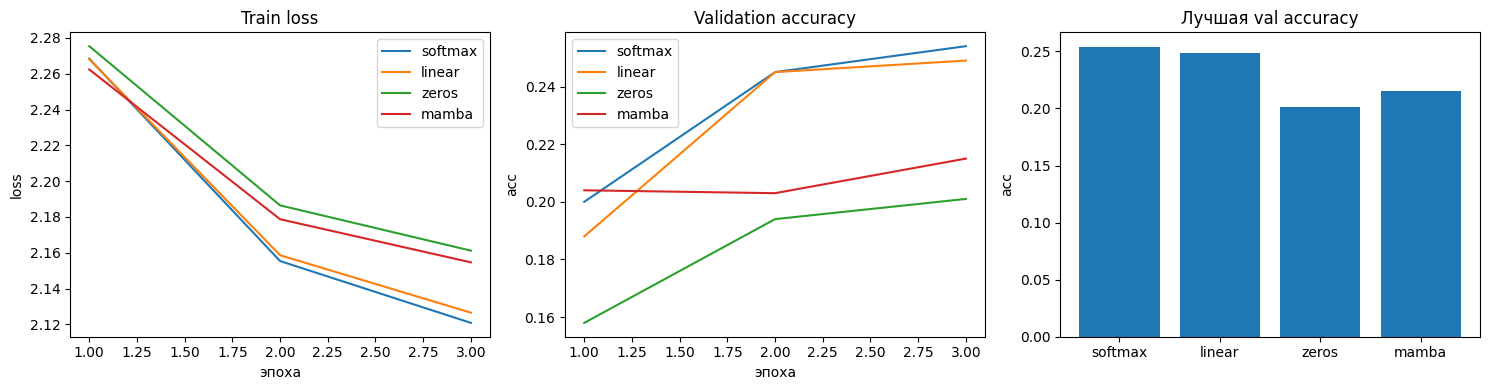

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for name, h in histories.items():
    ep = range(1, len(h["train_loss"]) + 1)
    ax[0].plot(ep, h["train_loss"], label=name)
    ax[1].plot(ep, h["val_acc"], label=name)
ax[0].set_title("Train loss"); ax[0].set_xlabel("эпоха"); ax[0].set_ylabel("loss"); ax[0].legend()
ax[1].set_title("Validation accuracy"); ax[1].set_xlabel("эпоха"); ax[1].set_ylabel("acc"); ax[1].legend()

names = list(histories.keys())
best = [max(histories[n]["val_acc"]) for n in names]
ax[2].bar(names, best)
ax[2].set_title("Лучшая val accuracy"); ax[2].set_ylabel("acc")
plt.tight_layout(); plt.show()

## Тест эффективности

In [ ]:
BENCH_L = [128, 256, 512, 1024, 2048, 4096, 8192]
BENCH_B = 4
Dm = CONFIG["d_model"]
bench_modules = {
    "softmax": SoftmaxAttention(Dm, CONFIG["n_heads"]).to(device),
    "linear": VanillaLinearAttention(Dm, CONFIG["n_heads"]).to(device),
    "zeros": ZeroSLinear(Dm, CONFIG["n_heads"]).to(device),
}

fwd_lat = {n: [] for n in bench_modules}
fb_lat = {n: [] for n in bench_modules}
peak = {n: [] for n in bench_modules}

for name, mod in bench_modules.items():
    for L in BENCH_L:
        try:
            x = torch.randn(BENCH_B, L, Dm, device=device)

            def fwd():
                with torch.no_grad():
                    mod(x)

            def fb():
                mod.zero_grad()
                out = mod(x)
                out.sum().backward()

            fwd_lat[name].append(timeit(fwd, device))
            fb_lat[name].append(timeit(fb, device, warmup=2, iters=5))
            peak[name].append(peak_mem_mb(fwd, device))
        except (RuntimeError, torch.cuda.OutOfMemoryError) as e:
            print(f"{name} L={L}: OOM/ошибка ({type(e).__name__})")
            if device.type == "cuda":
                torch.cuda.empty_cache()
            fwd_lat[name].append(float("nan"))
            fb_lat[name].append(float("nan"))
            peak[name].append(float("nan"))
    print(f"{name}: forward latency (мс) =", [f"{1000*v:.2f}" if v == v else "OOM" for v in fwd_lat[name]])

softmax: forward latency (мс) = ['0.37', '0.36', '0.37', '0.45', '1.15', '3.89', '15.29']
linear: forward latency (мс) = ['1.20', '1.21', '1.27', '1.20', '1.19', '1.19', '1.20']
zeros: forward latency (мс) = ['3.39', '3.40', '3.62', '3.58', '3.57', '3.58', '3.51']


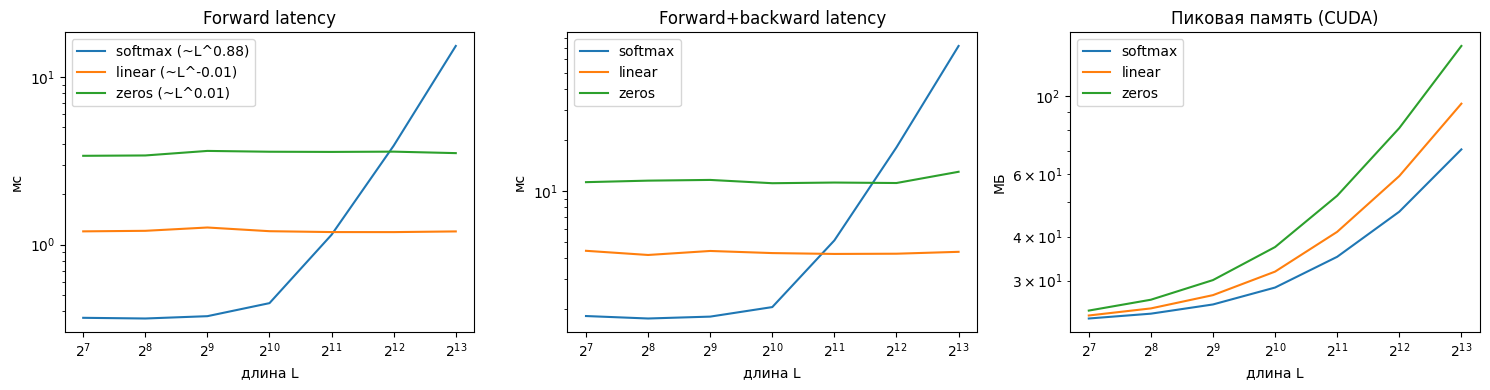

Наклон log-log forward latency:
  softmax : L^0.88
  linear  : L^-0.01
  zeros   : L^0.01


In [ ]:
def fit_slope(L, y):
    L, y = np.array(L), np.array(y)
    mask = np.isfinite(y) & (y > 0)
    if mask.sum() < 2:
        return float("nan")
    return np.polyfit(np.log(L[mask]), np.log(y[mask]), 1)[0]


fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for name in bench_modules:
    sl = fit_slope(BENCH_L, fwd_lat[name])
    ax[0].plot(BENCH_L, [1000 * v for v in fwd_lat[name]], label=f"{name} (~L^{sl:.2f})")
    ax[1].plot(BENCH_L, [1000 * v for v in fb_lat[name]], label=name)
    if np.isfinite(peak[name]).any():
        ax[2].plot(BENCH_L, peak[name], label=name)

ax[0].set_title("Forward latency"); ax[0].set_ylabel("мс")
ax[1].set_title("Forward+backward latency"); ax[1].set_ylabel("мс")
ax[2].set_title("Пиковая память (CUDA)"); ax[2].set_ylabel("МБ")
for a in ax:
    a.set_xscale("log", base=2); a.set_yscale("log"); a.set_xlabel("длина L"); a.legend()
if not np.isfinite(peak["softmax"]).any():
    ax[2].text(0.5, 0.5, "память доступна только на CUDA", ha="center", va="center", transform=ax[2].transAxes)
plt.tight_layout(); plt.show()

print("Наклон log-log forward latency:")
for name in bench_modules:
    print(f"  {name:8s}: L^{fit_slope(BENCH_L, fwd_lat[name]):.2f}")

## Графики ZeroS

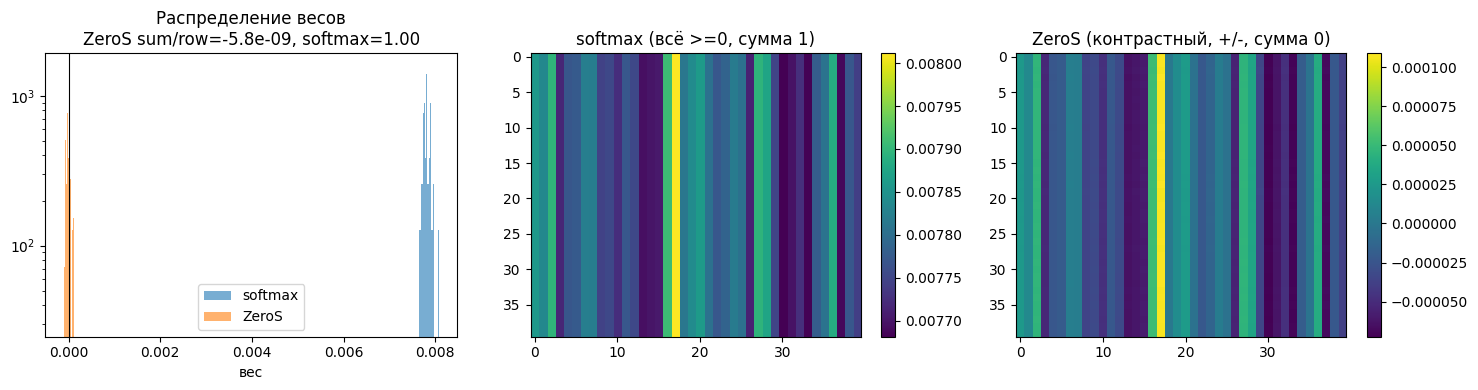

ZeroS: доля отрицательных весов = 52.34%, средняя сумма строки = -5.84e-09
softmax: доля отрицательных = 0.00%, средняя сумма строки = 1.0000


In [ ]:
trained = models["zeros"]
probe = ZeroSExplicit(CONFIG["d_model"], CONFIG["n_heads"], use_associative=True).to(device)
probe.load_state_dict(trained.blocks[0].attn.state_dict())
probe.eval()

xb, _ = next(iter(test_loader))
N = 128
xs = xb[:1, :N].to(device)
with torch.no_grad():
    emb = trained.embed(xs) + trained.pos[:, :N]
    emb = trained.blocks[0].norm1(emb)
    _, _, w_base = probe(emb, return_weights=True)
    s = probe.split(probe.key_logit(emb), 1, N).squeeze(-1)
    w_soft = torch.softmax(s.unsqueeze(2).expand(1, probe.n_heads, N, N), dim=-1)

wz = w_base[0, 0].cpu().numpy()
ws = w_soft[0, 0].cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(ws.ravel(), bins=60, alpha=0.6, label="softmax")
ax[0].hist(wz.ravel(), bins=60, alpha=0.6, label="ZeroS")
ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_title(f"Распределение весов\nZeroS sum/row={wz.sum(1).mean():.1e}, softmax={ws.sum(1).mean():.2f}")
ax[0].set_xlabel("вес"); ax[0].set_yscale("log"); ax[0].legend()

im1 = ax[1].imshow(ws[:40, :40], aspect="auto")
ax[1].set_title("softmax (всё >=0, сумма 1)"); plt.colorbar(im1, ax=ax[1])
im2 = ax[2].imshow(wz[:40, :40], aspect="auto")
ax[2].set_title("ZeroS (контрастный, +/-, сумма 0)"); plt.colorbar(im2, ax=ax[2])
plt.tight_layout(); plt.show()

print(f"ZeroS: доля отрицательных весов = {(wz < 0).mean():.2%}, средняя сумма строки = {wz.sum(1).mean():.2e}")
print(f"softmax: доля отрицательных = {(ws < 0).mean():.2%}, средняя сумма строки = {ws.sum(1).mean():.4f}")

In [ ]:
ablations = {
    "ZeroS полный": ZeroSExplicit(CONFIG["d_model"], CONFIG["n_heads"], use_associative=True, use_zero_order=False),
    "+ нулевой порядок": ZeroSExplicit(CONFIG["d_model"], CONFIG["n_heads"], use_associative=True, use_zero_order=True),
    "без cos-гейтинга": ZeroSExplicit(CONFIG["d_model"], CONFIG["n_heads"], use_associative=False, use_zero_order=False),
}

abl_rows = []
for label, mod in ablations.items():
    mod.load_state_dict(trained.blocks[0].attn.state_dict())
    mod = mod.to(device).eval()
    with torch.no_grad():
        _, w, _ = mod(emb, return_weights=True)
    w = w[0, 0].cpu().numpy()
    abl_rows.append({
        "вариант": label,
        "доля отриц. весов": f"{(w < 0).mean():.1%}",
        "|сумма строки|": f"{np.abs(w.sum(1)).mean():.1e}",
        "std весов": f"{w.std():.3e}",
    })
show_table(abl_rows)

вариант            доля отриц. весов  |сумма строки|  std весов
-----------------  -----------------  --------------  ---------
ZeroS полный       47.7%              1.9e-06         5.961e-06
+ нулевой порядок  100.0%             2.2e-02         2.008e-05
без cos-гейтинга   52.3%              5.8e-09         4.507e-05


## Выводы


| механизм | params | best val-acc | final train-loss |
|---|---|---|---|
| softmax | 166 986 | 0.2540 | 2.1208 |
| linear | 166 986 | 0.2490 | n/a |
| mamba | 165 357 | 0.2150 | n/a |
| zeros | 170 106 | 0.2010 | 2.1612 |

самописный ZeroS хуже всех - сходится медленнее, train-loss наибольший, из-за коротких последовательностий. Реализован верно, формы совпадают до 10^-8 при O(N). 